In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_100226/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [3]:
data = processed_data_30cm

In [4]:
freqs = list(data.keys())
volts = []

for i in range(len(freqs)):
    volts.append(list(data[freqs[i]].keys()))

In [14]:
periods = [1/f for f in freqs]
print("Time between peaks (periods):", periods)

Time between peaks (periods): [1.1135857461024499, 1.0204081632653061, 0.942507068803016, 0.8748906386701663, 0.8163265306122448, 0.7656967840735068, 0.7204610951008646, 0.6802721088435374]


In [16]:
(1/250) * 100

0.4

Frequency: 0.898, Voltage: 0.149


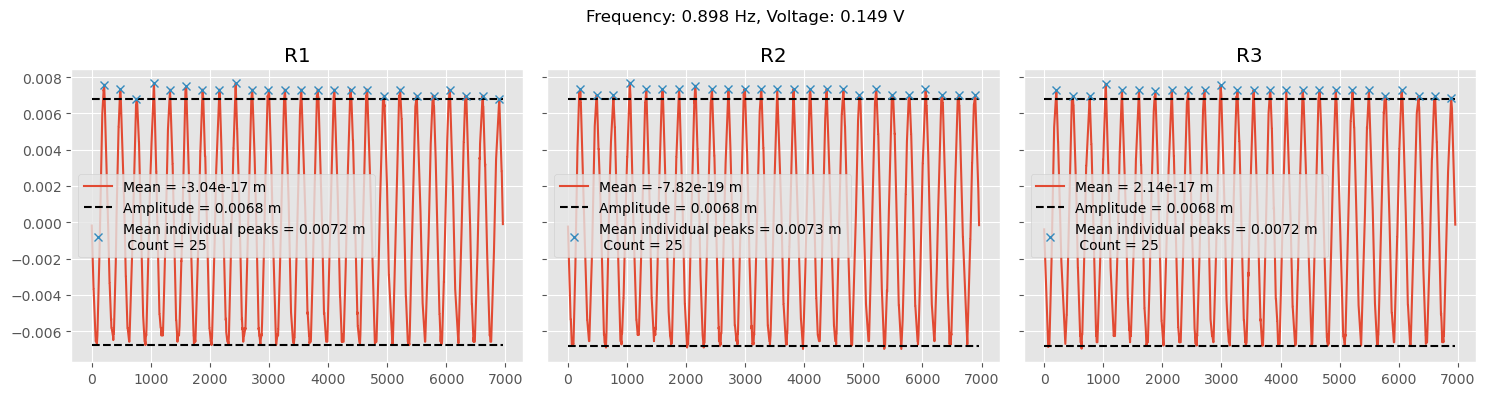

Frequency: 0.898, Voltage: 0.299


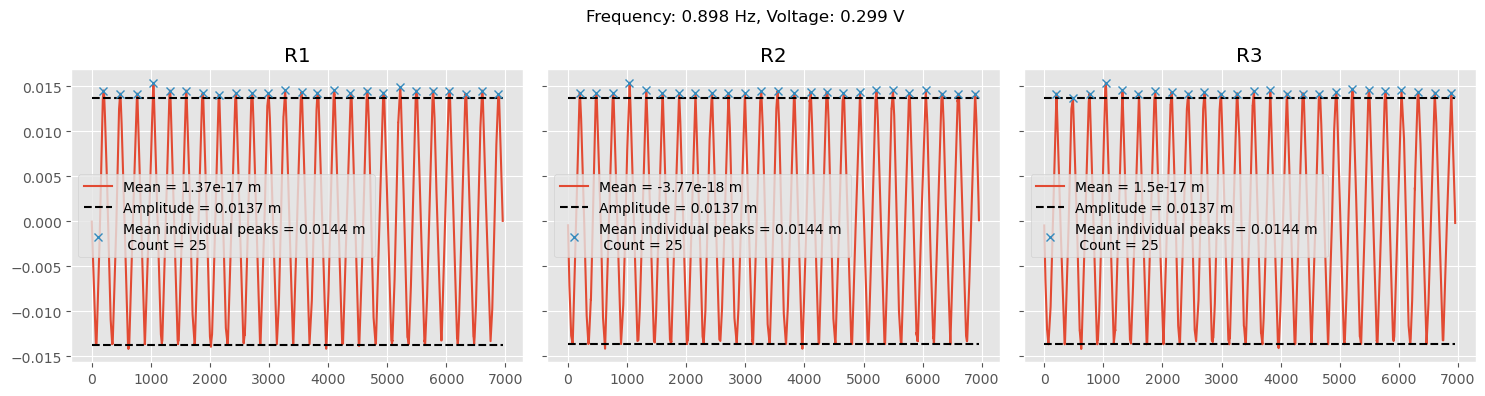

Frequency: 0.898, Voltage: 0.453


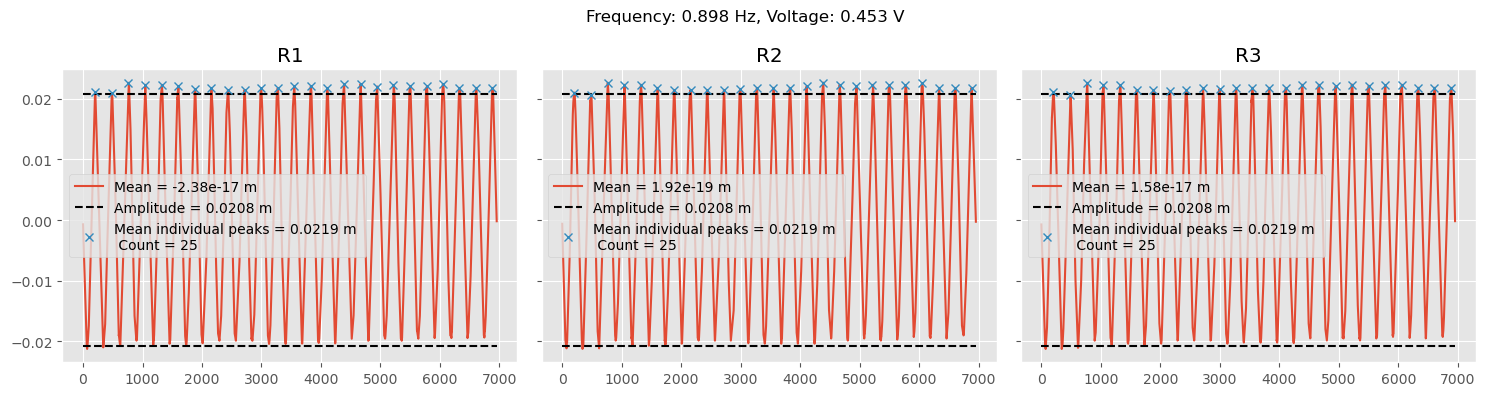

Frequency: 0.98, Voltage: 0.149


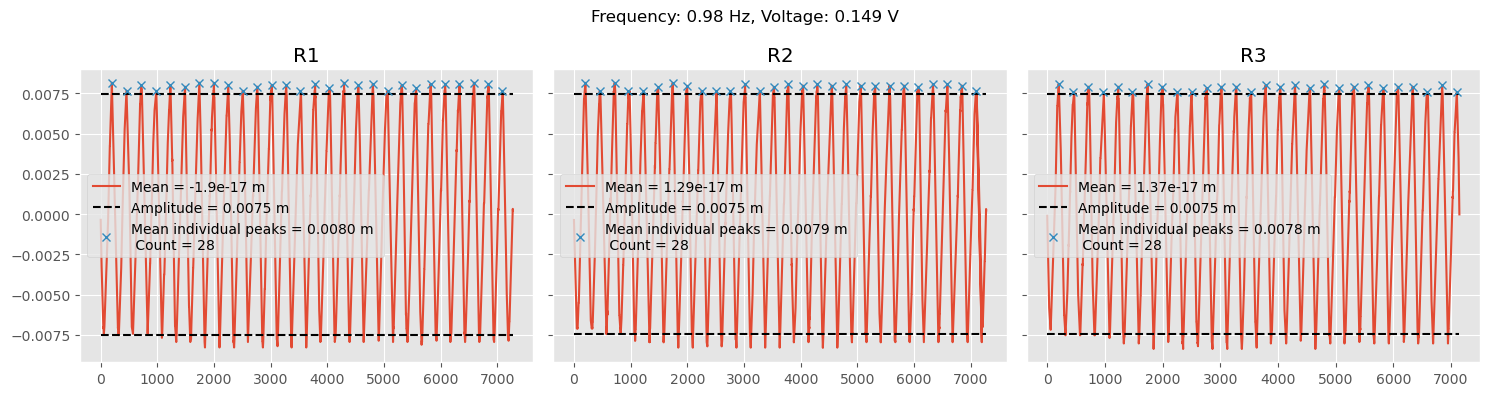

Frequency: 0.98, Voltage: 0.295


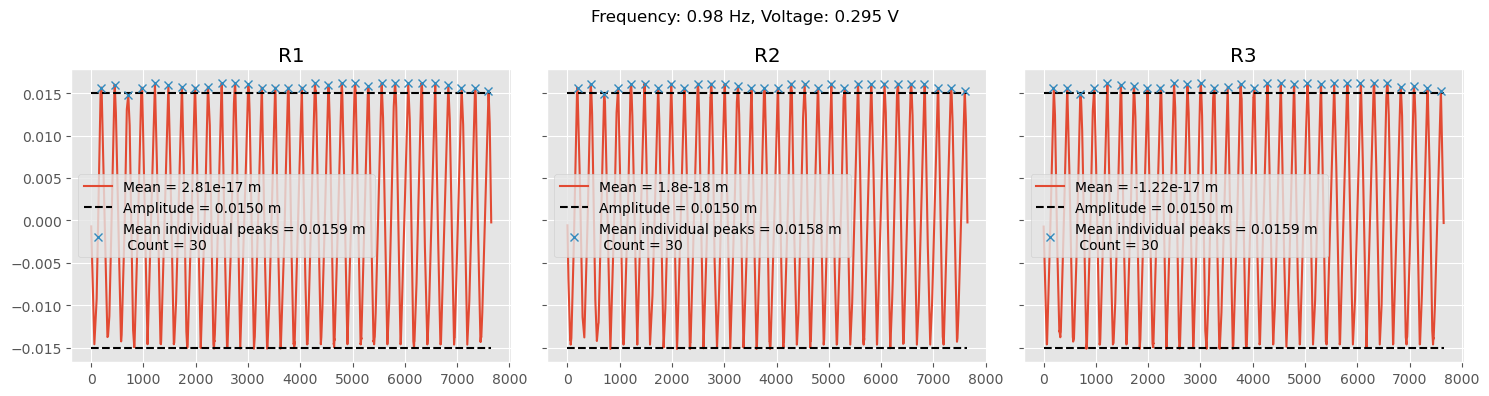

Frequency: 0.98, Voltage: 0.443


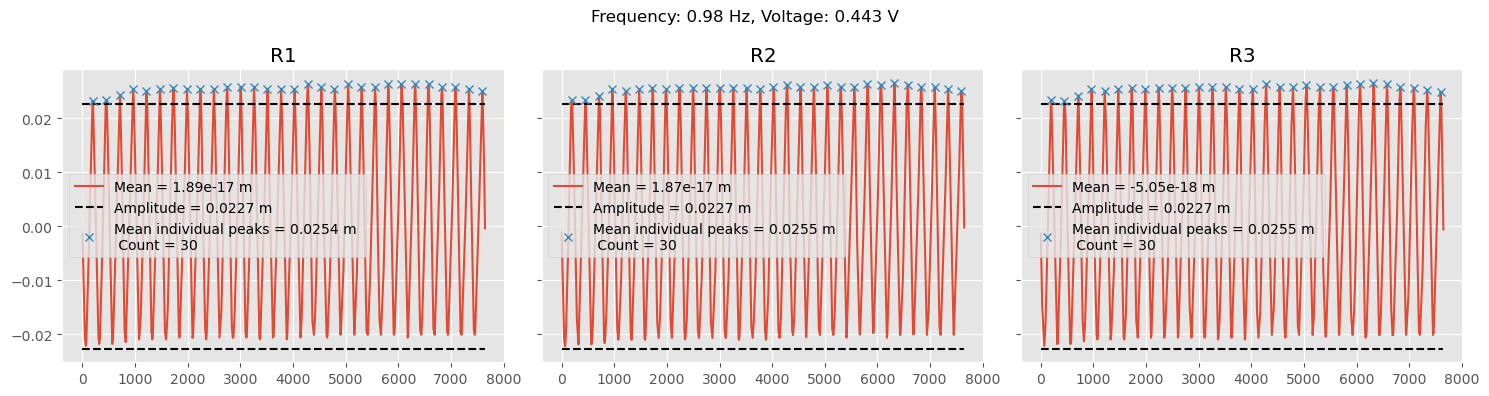

Frequency: 1.061, Voltage: 0.149


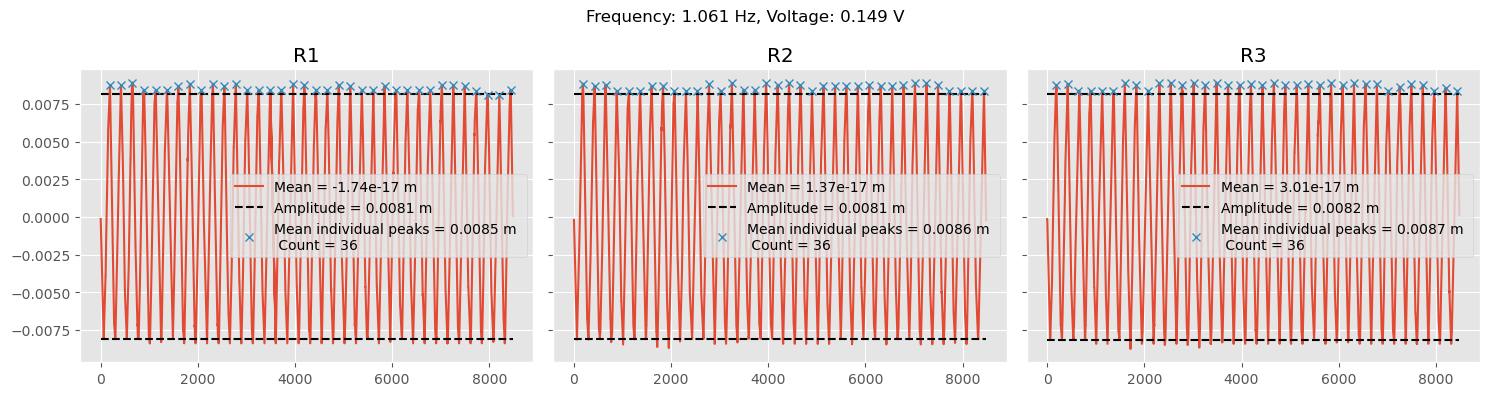

Frequency: 1.061, Voltage: 0.295


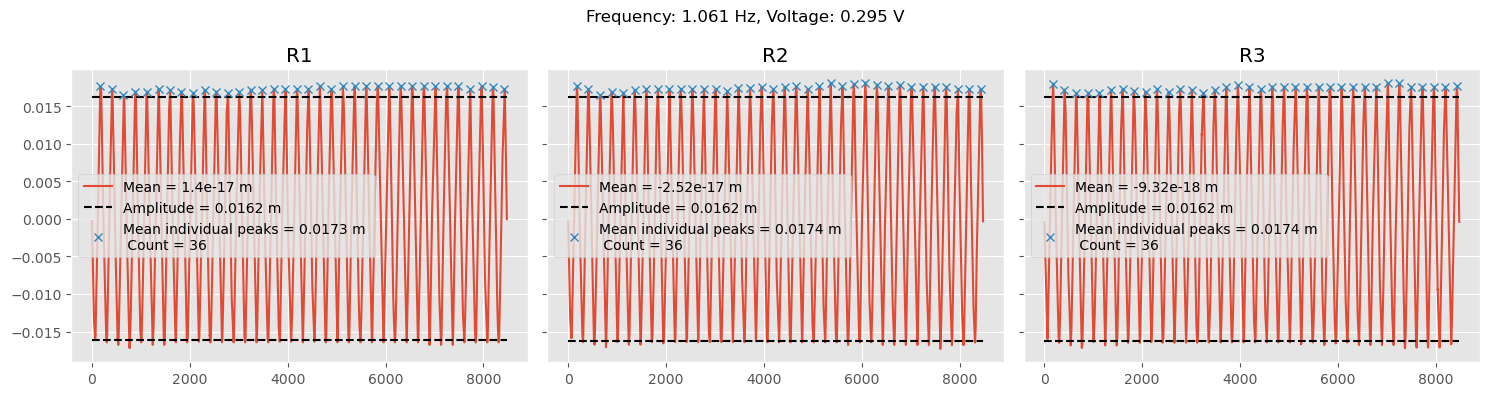

Frequency: 1.061, Voltage: 0.449


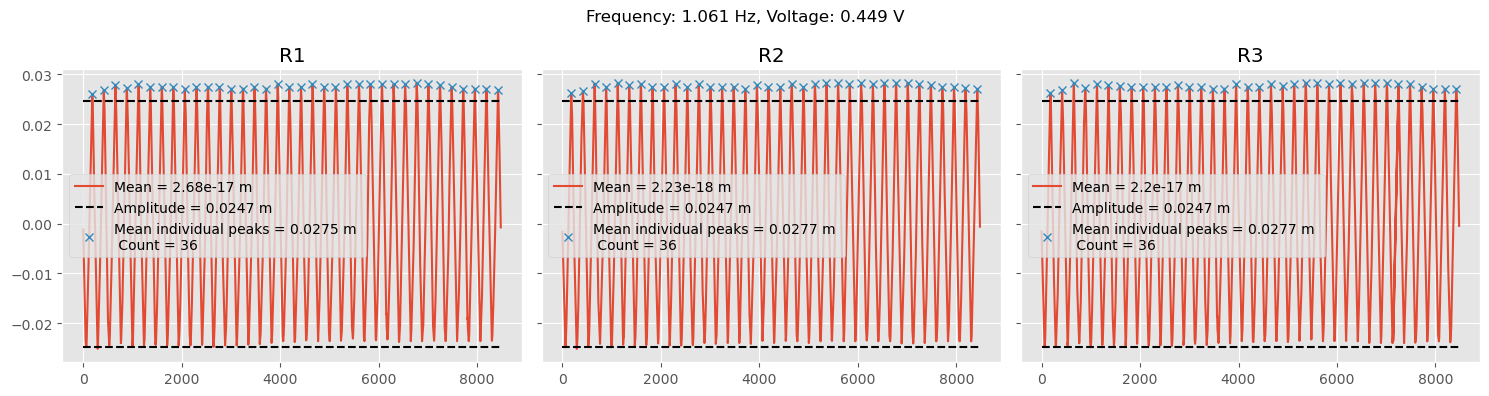

Frequency: 1.143, Voltage: 0.148


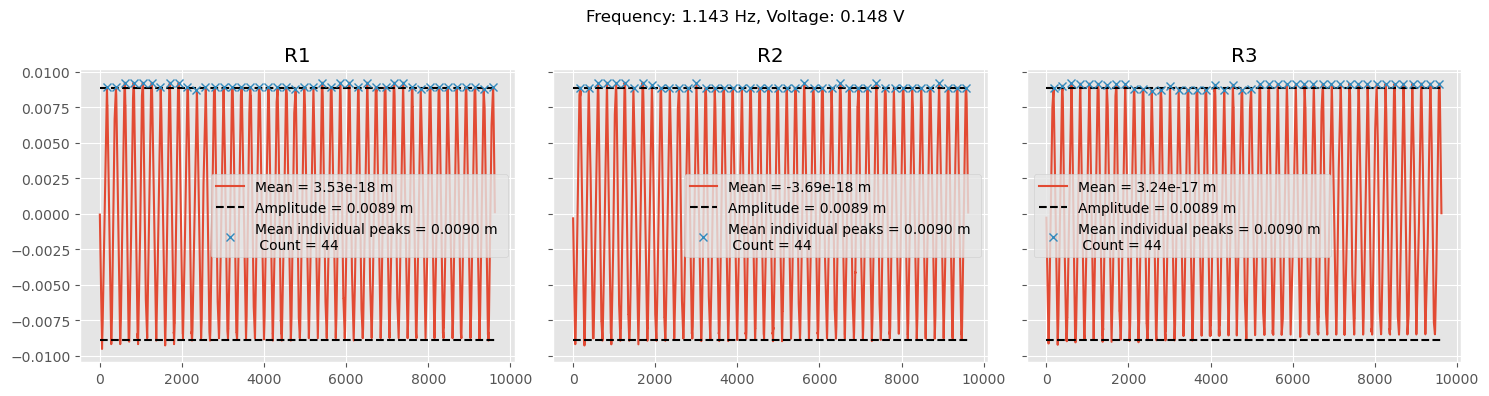

Frequency: 1.143, Voltage: 0.295


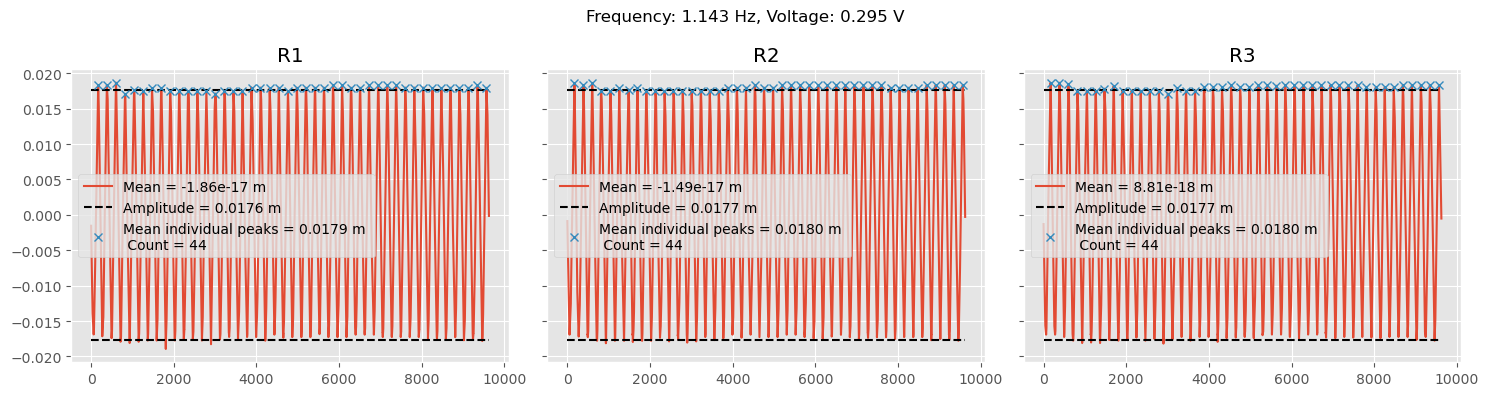

Frequency: 1.143, Voltage: 0.443


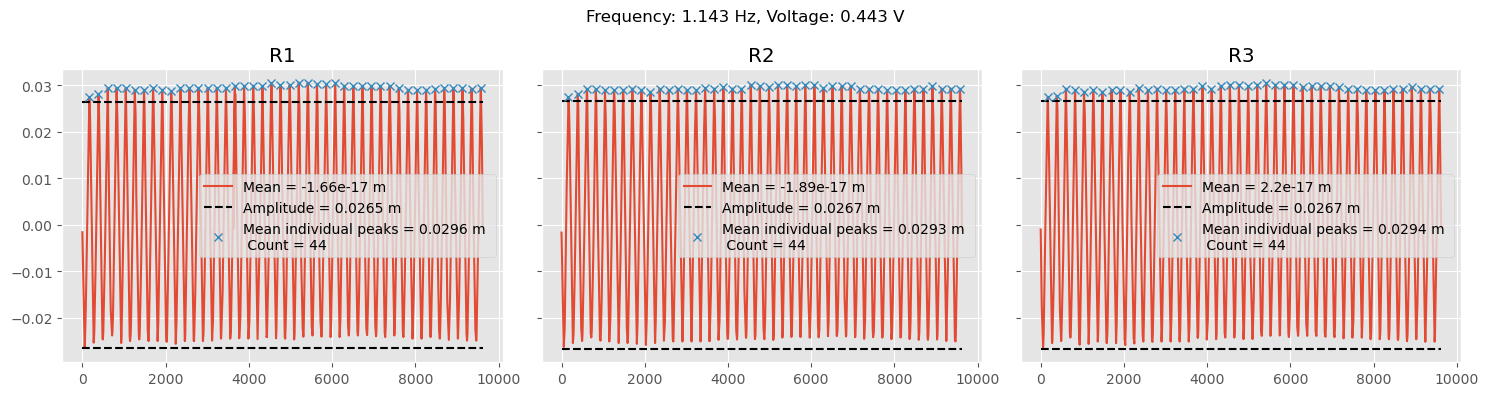

Frequency: 1.225, Voltage: 0.152


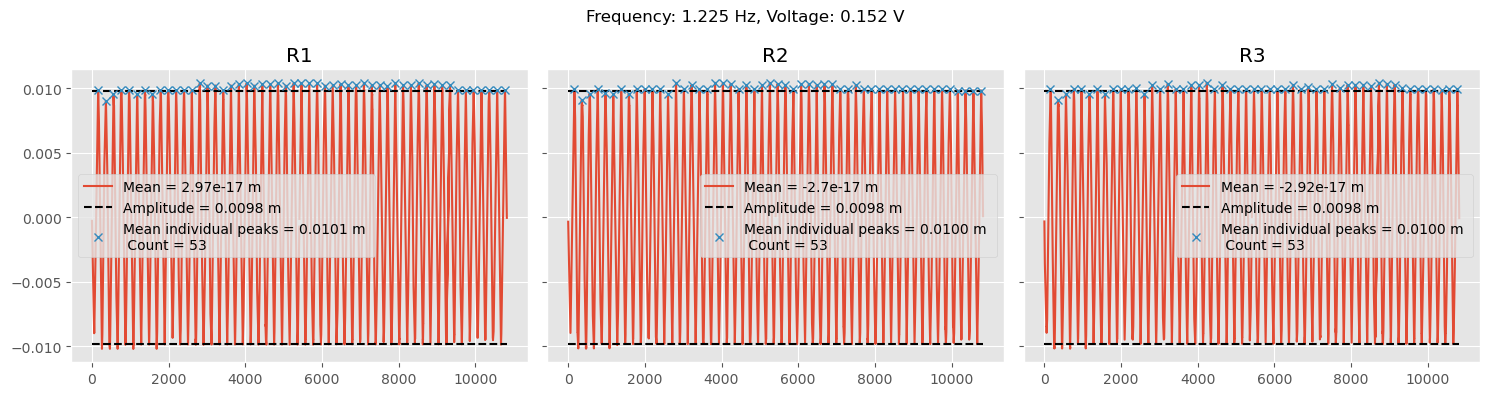

Frequency: 1.225, Voltage: 0.299


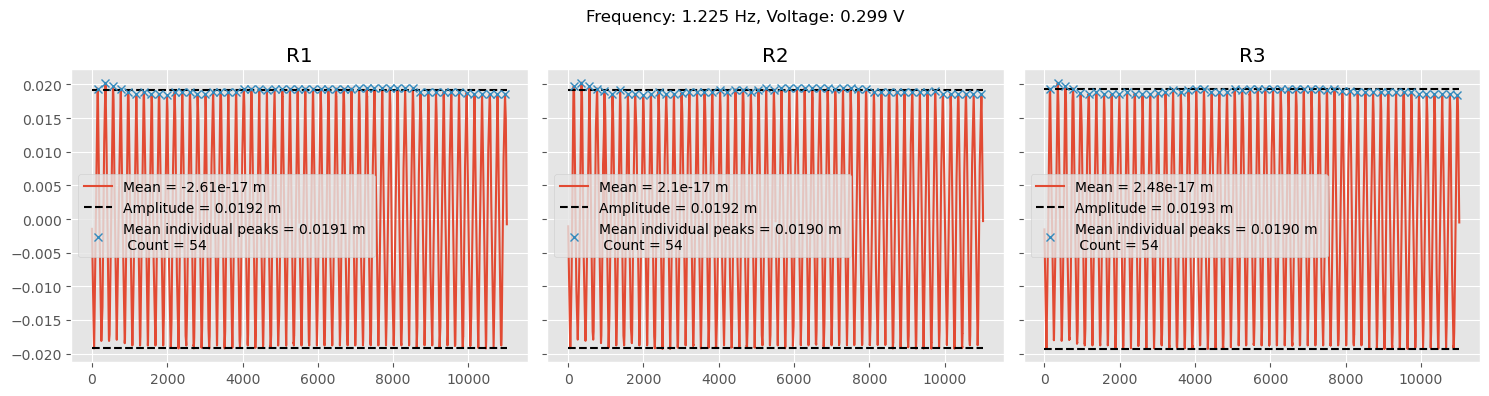

Frequency: 1.225, Voltage: 0.471


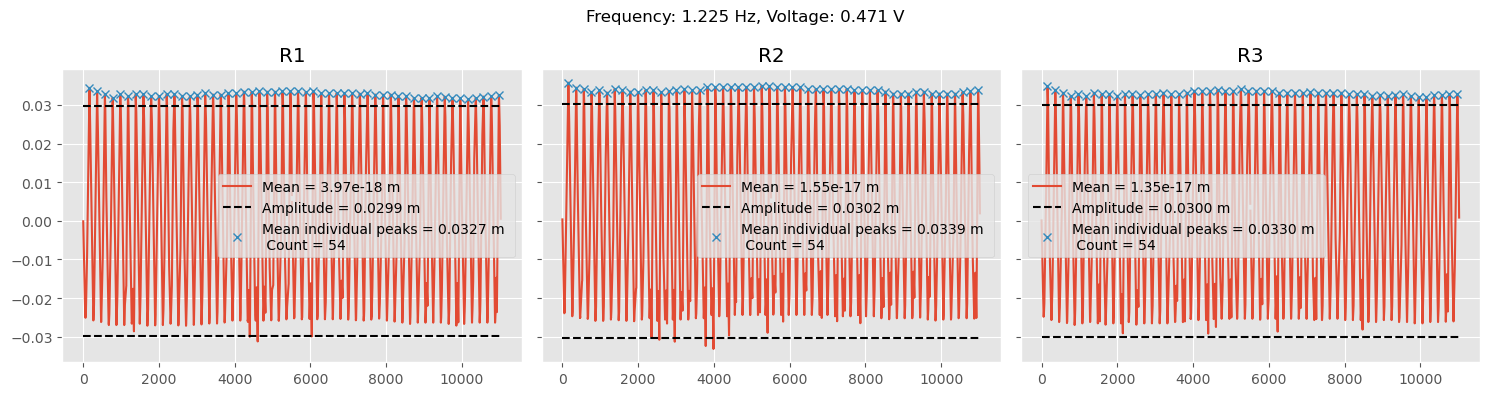

Frequency: 1.306, Voltage: 0.152


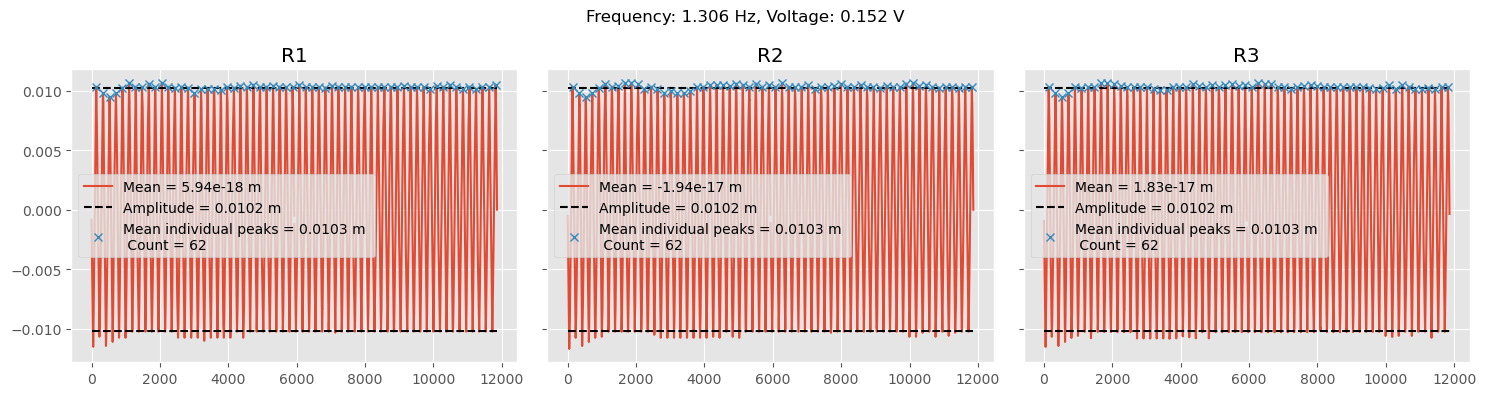

Frequency: 1.306, Voltage: 0.302


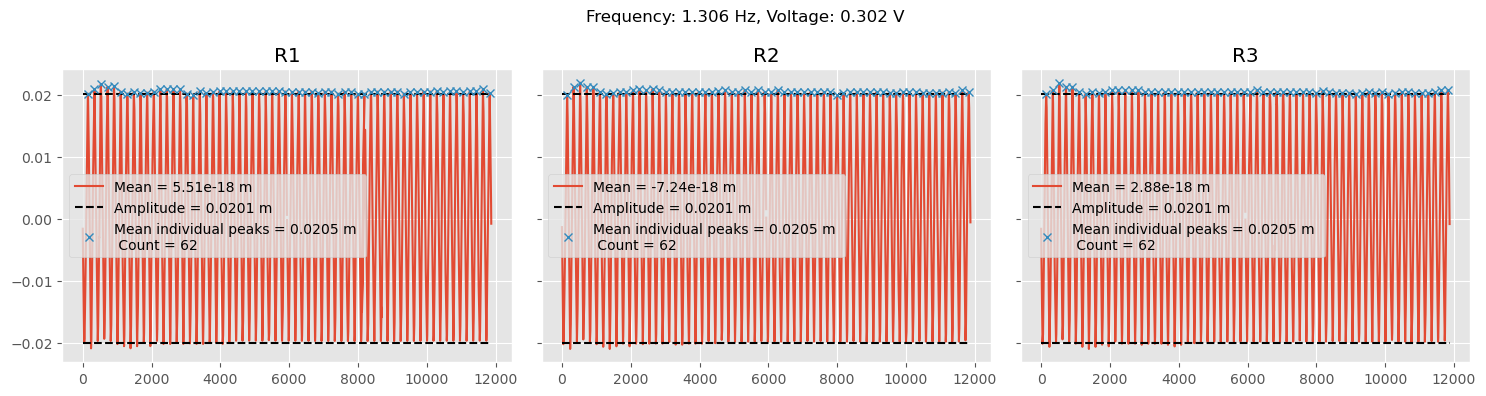

Frequency: 1.306, Voltage: 0.372


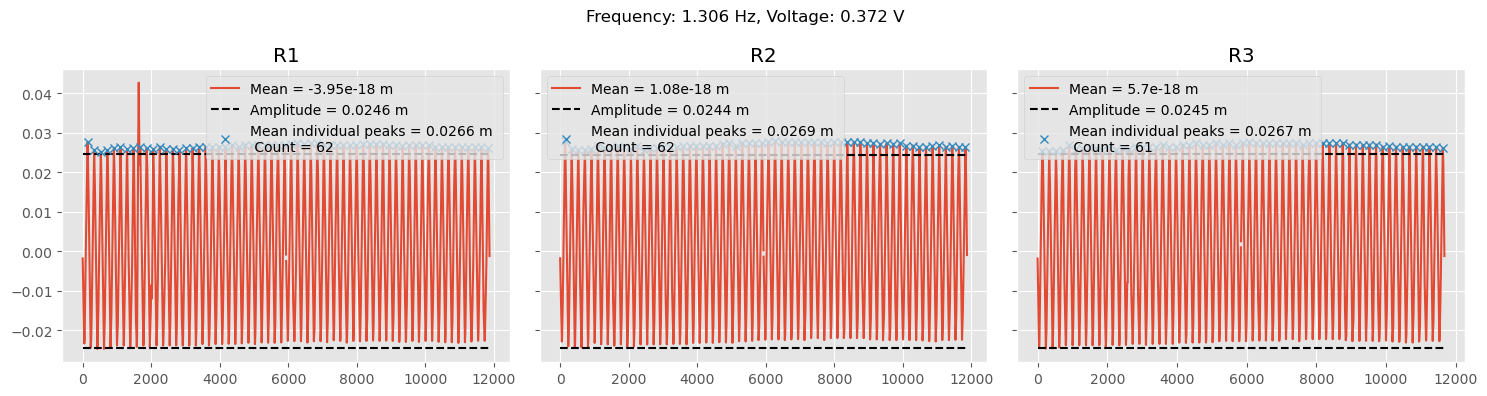

Frequency: 1.306, Voltage: 0.461


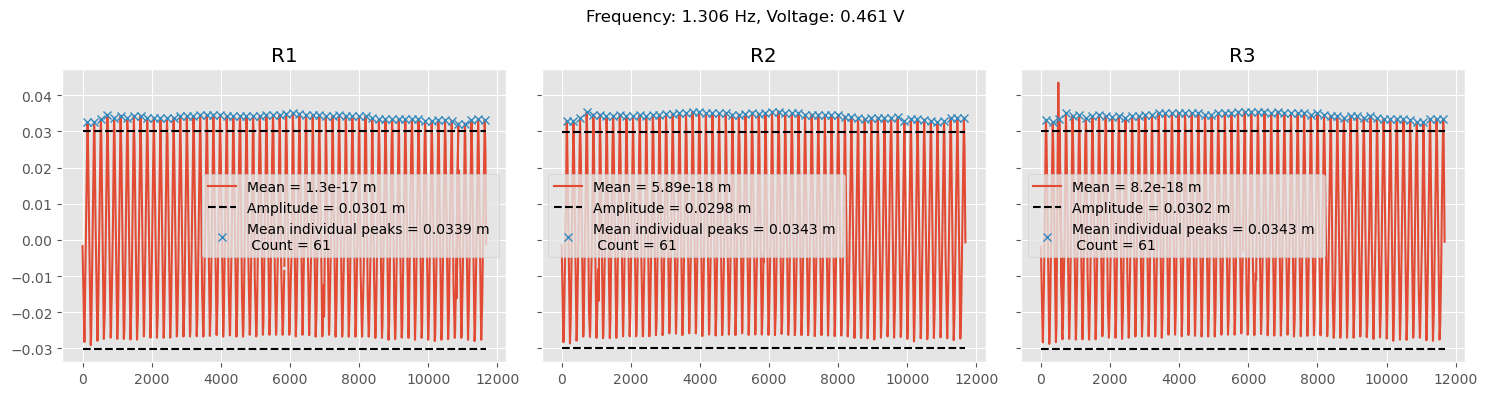

Frequency: 1.388, Voltage: 0.147


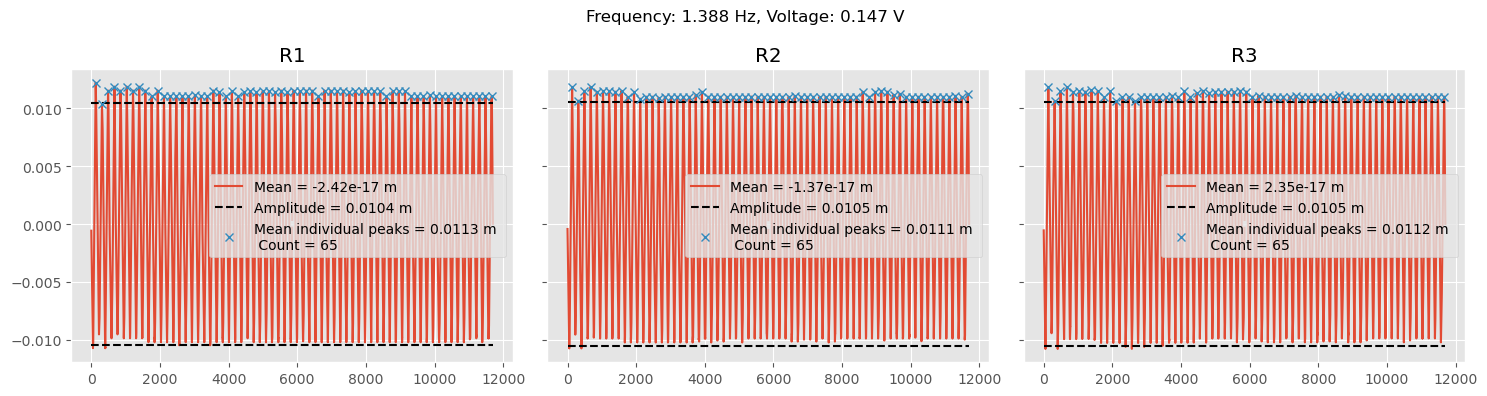

Frequency: 1.388, Voltage: 0.285


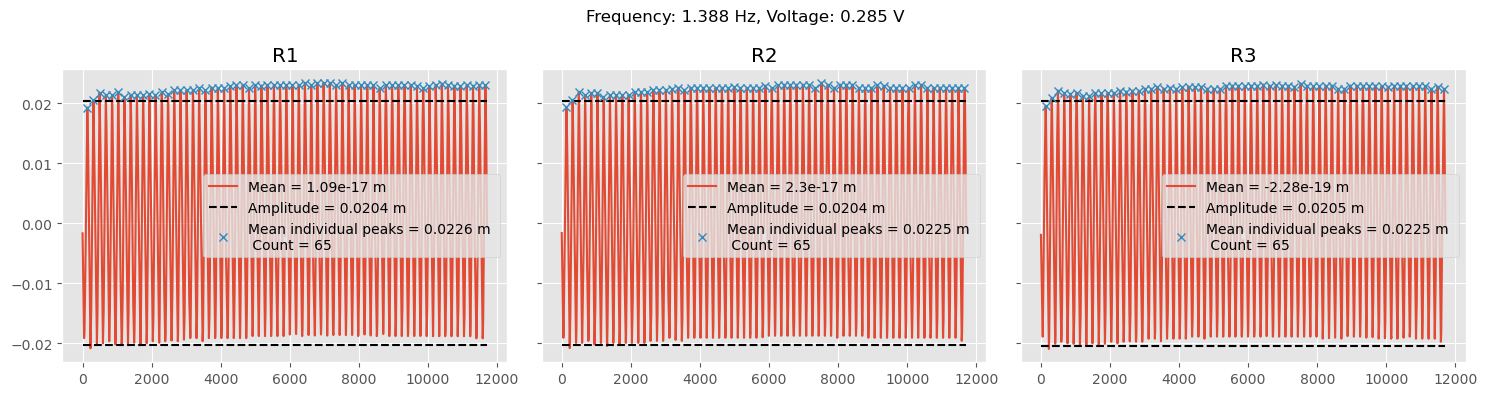

Frequency: 1.388, Voltage: 0.378


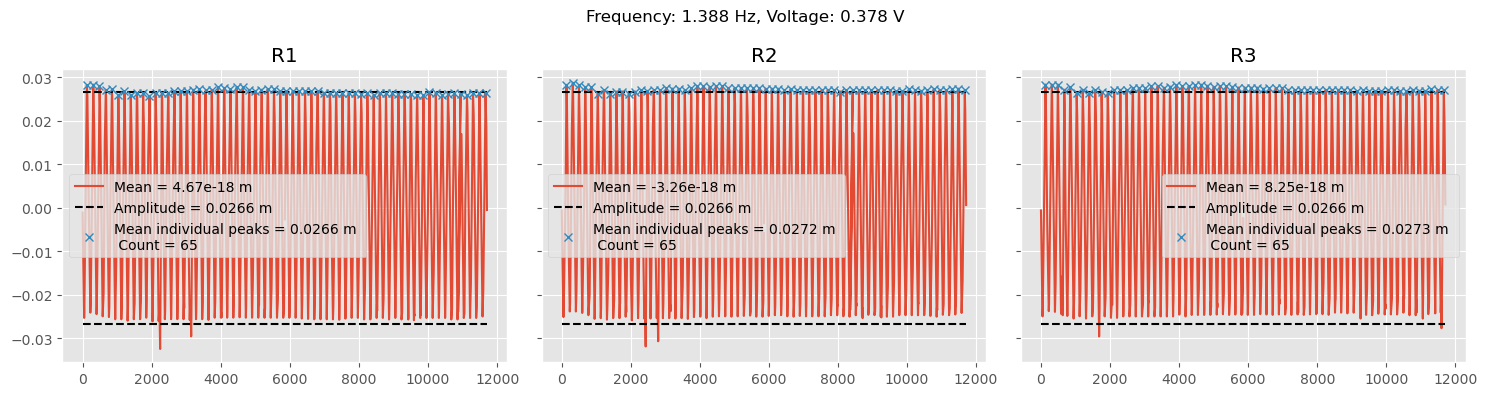

Frequency: 1.388, Voltage: 0.468


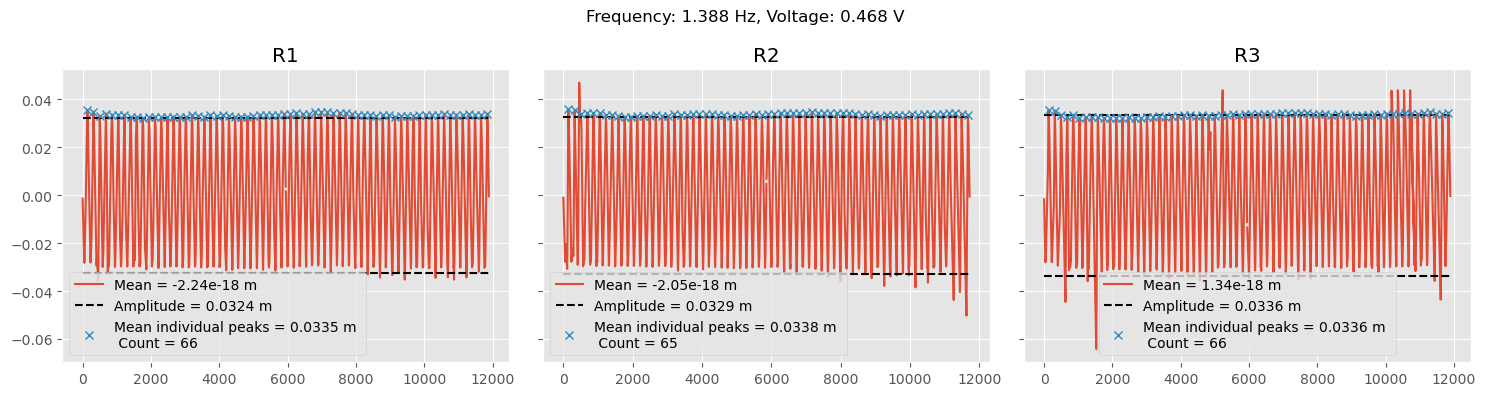

Frequency: 1.47, Voltage: 0.147


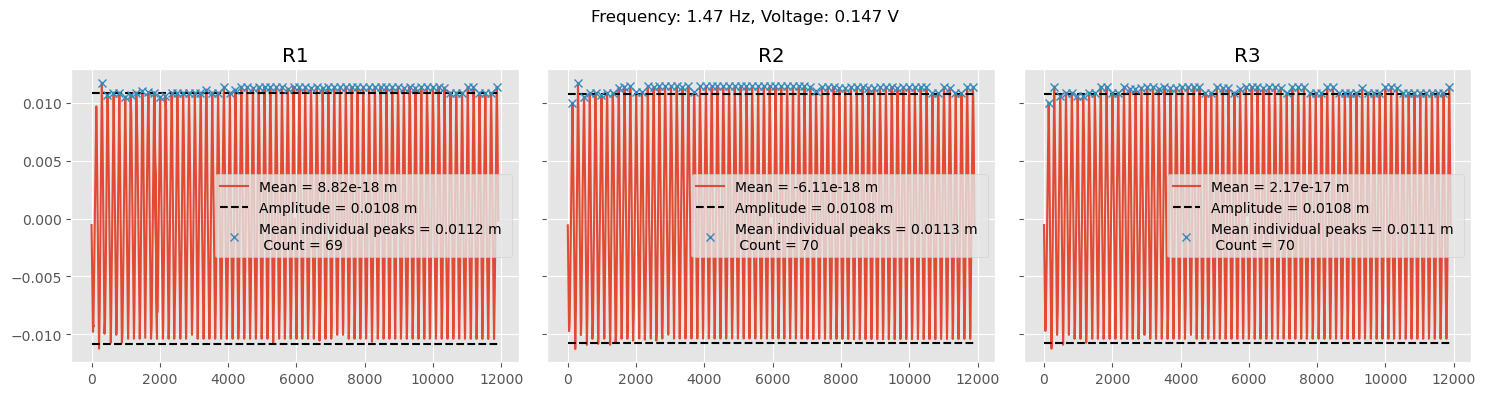

Frequency: 1.47, Voltage: 0.296


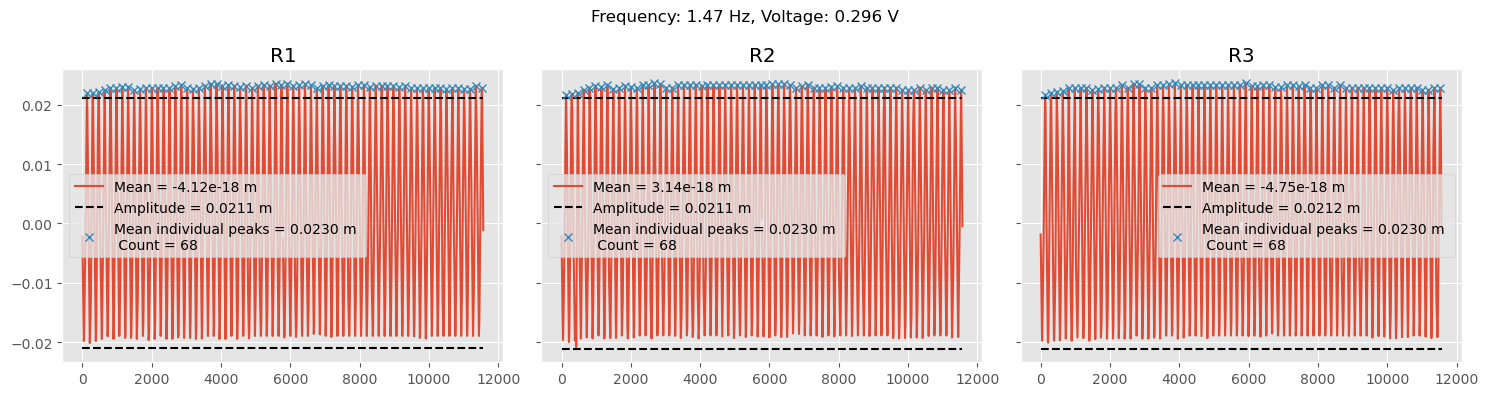

Frequency: 1.47, Voltage: 0.382


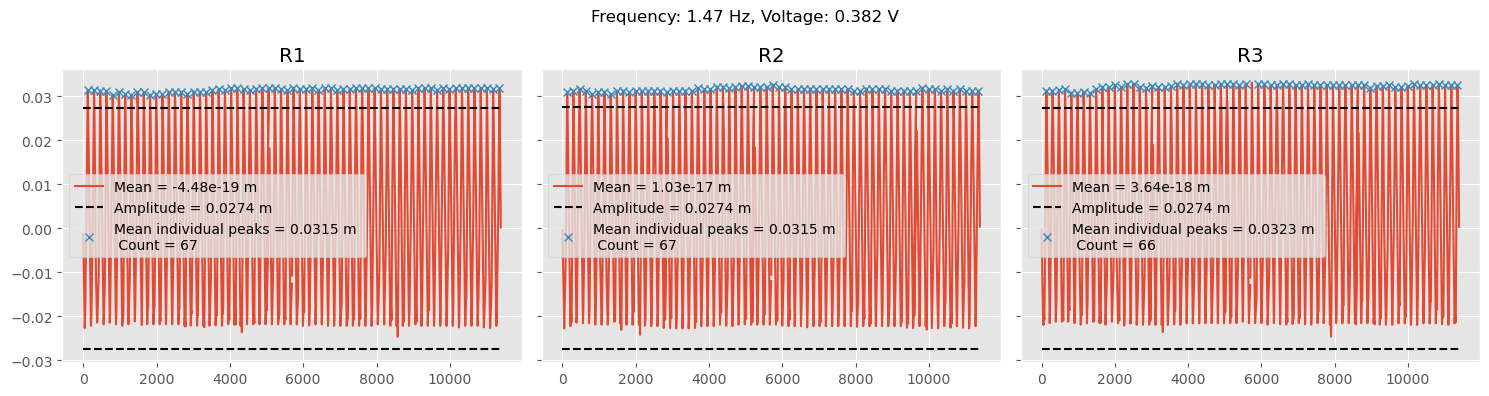

Frequency: 1.47, Voltage: 0.459


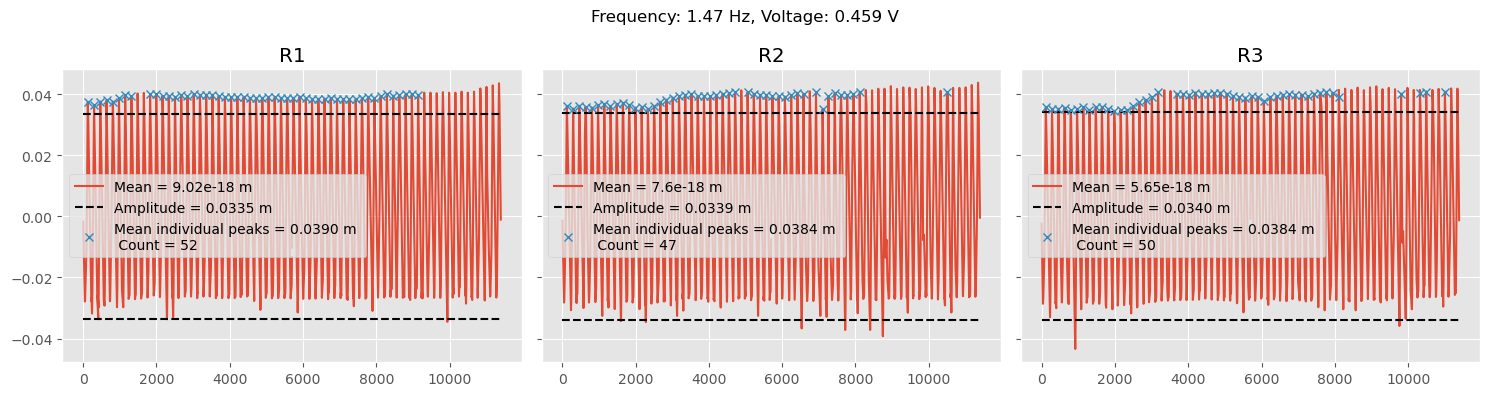

In [17]:
for i, f in enumerate(freqs):
        for v in volts[i]:
                print(f"Frequency: {f}, Voltage: {v}")
                eta_r1 = data[f][v][None]["R1"]
                eta_r2 = data[f][v][None]["R2"]
                eta_r3 = data[f][v][None]["R3"]

                P0_r1 = eta_r1["P_0"].dropna().values * (-1)
                P0_r2 = eta_r2["P_0"].dropna().values * (-1)
                P0_r3 = eta_r3["P_0"].dropna().values * (-1)

                std_P0_r1 = np.std(P0_r1)
                std_P0_r2 = np.std(P0_r2)
                std_P0_r3 = np.std(P0_r3)

                amp_P0_r1 = np.sqrt(2) * std_P0_r1
                amp_P0_r2 = np.sqrt(2) * std_P0_r2
                amp_P0_r3 = np.sqrt(2) * std_P0_r3

                # Comapring variance method to scipy find_peaks
                peak_idx_r1 = sc.signal.find_peaks(P0_r1, height=(0.9*np.sqrt(2)*std_P0_r1, 1.2*np.sqrt(2)*std_P0_r1), distance=100)[0]
                peak_idx_r2 = sc.signal.find_peaks(P0_r2, height=(0.9*np.sqrt(2)*std_P0_r2, 1.2*np.sqrt(2)*std_P0_r2), distance=100)[0]
                peak_idx_r3 = sc.signal.find_peaks(P0_r3, height=(0.9*np.sqrt(2)*std_P0_r3, 1.2*np.sqrt(2)*std_P0_r3), distance=100)[0]

                sc_peaks_r1 = P0_r1[peak_idx_r1]
                sc_peaks_r2 = P0_r2[peak_idx_r2]
                sc_peaks_r3 = P0_r3[peak_idx_r3]

                # Only keep positive peaks
                sc_peaks_r1 = sc_peaks_r1[sc_peaks_r1 > 0]
                sc_peaks_r2 = sc_peaks_r2[sc_peaks_r2 > 0]
                sc_peaks_r3 = sc_peaks_r3[sc_peaks_r3 > 0]

                fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
                ax[0].plot(P0_r1, color='C0', label=f'Mean = {np.mean(P0_r1):.3g} m')
                ax[1].plot(P0_r2, color='C0', label=f'Mean = {np.mean(P0_r2):.3g} m')
                ax[2].plot(P0_r3, color='C0', label=f'Mean = {np.mean(P0_r3):.3g} m')

                ax[0].hlines(amp_P0_r1, xmin=0, xmax=len(P0_r1)-1, color='k', linestyle='--', label=f"Amplitude = {amp_P0_r1:.4f} m")
                ax[0].hlines(-amp_P0_r1, xmin=0, xmax=len(P0_r1)-1, color='k', linestyle='--')
                ax[1].hlines(amp_P0_r2, xmin=0, xmax=len(P0_r2)-1, color='k', linestyle='--', label=f"Amplitude = {amp_P0_r2:.4f} m")
                ax[1].hlines(-amp_P0_r2, xmin=0, xmax=len(P0_r2)-1, color='k', linestyle='--')
                ax[2].hlines(amp_P0_r3, xmin=0, xmax=len(P0_r3)-1, color='k', linestyle='--', label=f"Amplitude = {amp_P0_r3:.4f} m")
                ax[2].hlines(-amp_P0_r3, xmin=0, xmax=len(P0_r3)-1, color='k', linestyle='--')  

                # Scipy find peaks
                ax[0].plot(peak_idx_r1, sc_peaks_r1, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r1):.4f} m \n Count = {len(sc_peaks_r1)}')
                ax[1].plot(peak_idx_r2, sc_peaks_r2, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r2):.4f} m \n Count = {len(sc_peaks_r2)}')
                ax[2].plot(peak_idx_r3, sc_peaks_r3, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r3):.4f} m \n Count = {len(sc_peaks_r3)}')

                ax[0].set_title("R1")
                ax[1].set_title("R2")
                ax[2].set_title("R3")

                ax[0].legend()
                ax[1].legend()
                ax[2].legend()

                fig.suptitle(f"Frequency: {f} Hz, Voltage: {v} V")
            
                plt.tight_layout()
                plt.show()
            

Frequency: 0.898, Voltage: 0.149


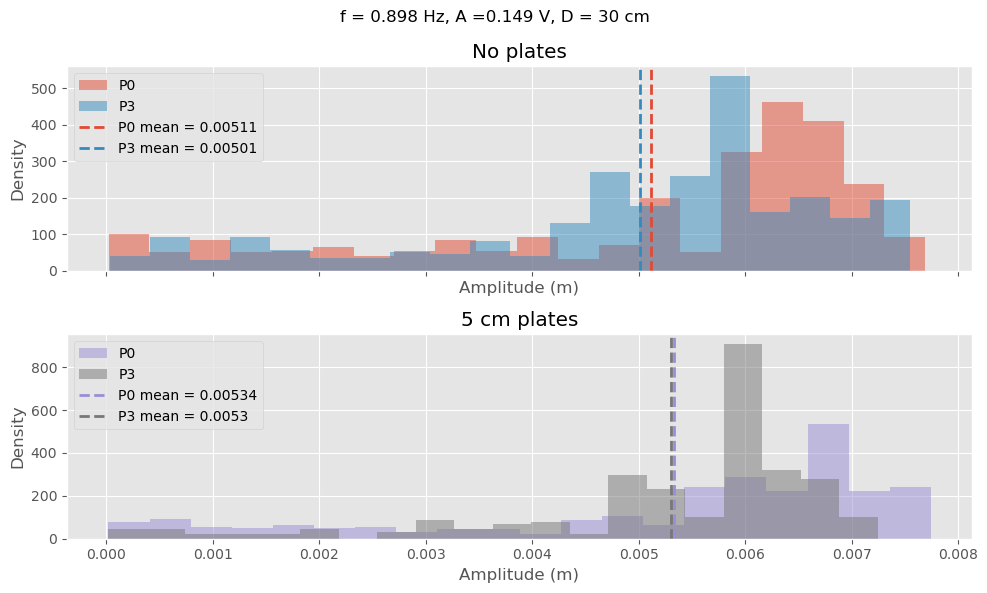

FileNotFoundError: [Errno 2] No such file or directory: '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Analysis/figs/amp_dist/freq_0.898_volt_0.149.png'

<Figure size 640x480 with 0 Axes>

In [ ]:
for i, f in enumerate(freqs):
        for v in volts[i]:
                print(f"Frequency: {f}, Voltage: {v}")
                # No plates
                eta_r1 = data[f][v][None]["R1"]
                eta_r2 = data[f][v][None]["R2"]
                eta_r3 = data[f][v][None]["R3"]

                P0_r1 = eta_r1["P_0"].dropna().values
                P0_r2 = eta_r2["P_0"].dropna().values
                P0_r3 = eta_r3["P_0"].dropna().values

                P3_r1 = eta_r1["P_3"].dropna().values
                P3_r2 = eta_r2["P_3"].dropna().values
                P3_r3 = eta_r3["P_3"].dropna().values

                amps_P0_r1 = get_amplitudes_from_run(P0_r1)
                amps_P0_r2 = get_amplitudes_from_run(P0_r2)
                amps_P0_r3 = get_amplitudes_from_run(P0_r3)

                amps_P0 = np.concatenate((amps_P0_r1, amps_P0_r2, amps_P0_r3))

                amps_P3_r1 = get_amplitudes_from_run(P3_r1)
                amps_P3_r2 = get_amplitudes_from_run(P3_r2)
                amps_P3_r3 = get_amplitudes_from_run(P3_r3)

                amps_P3 = np.concatenate((amps_P3_r1, amps_P3_r2, amps_P3_r3))

                mu_P0 = np.mean(amps_P0)
                mu_P3 = np.mean(amps_P3)
                std_P0 = np.std(amps_P0)
                std_P3 = np.std(amps_P3)

                # With plates
                eta_r1_p = data[f][v]["p005"]["R1"]
                eta_r2_p = data[f][v]["p005"]["R2"]
                eta_r3_p = data[f][v]["p005"]["R3"]

                P0_r1_p = eta_r1_p["P_0"].dropna().values
                P0_r2_p = eta_r2_p["P_0"].dropna().values
                P0_r3_p = eta_r3_p["P_0"].dropna().values

                P3_r1_p = eta_r1_p["P_3"].dropna().values
                P3_r2_p = eta_r2_p["P_3"].dropna().values
                P3_r3_p = eta_r3_p["P_3"].dropna().values

                amps_P0_r1_p = get_amplitudes_from_run(P0_r1_p)
                amps_P0_r2_p = get_amplitudes_from_run(P0_r2_p)
                amps_P0_r3_p = get_amplitudes_from_run(P0_r3_p)

                amps_P0_p = np.concatenate((amps_P0_r1_p, amps_P0_r2_p, amps_P0_r3_p))
                amps_P3_r1_p = get_amplitudes_from_run(P3_r1_p)
                amps_P3_r2_p = get_amplitudes_from_run(P3_r2_p)
                amps_P3_r3_p = get_amplitudes_from_run(P3_r3_p)

                amps_P3_p = np.concatenate((amps_P3_r1_p, amps_P3_r2_p, amps_P3_r3_p))

                mu_P0_p = np.mean(amps_P0_p)
                mu_P3_p = np.mean(amps_P3_p)
                std_P0_p = np.std(amps_P0_p)
                std_P3_p = np.std(amps_P3_p)

                fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

                # Histograms (normalized)
                ax[0].hist(amps_P0, bins=20, alpha=0.5, color='C0', label="P0", density=True)
                ax[0].hist(amps_P3, bins=20, alpha=0.5, color='C1', label="P3", density=True)

                ax[1].hist(amps_P0_p, bins=20, alpha=0.5, color='C2', label="P0", density=True)
                ax[1].hist(amps_P3_p, bins=20, alpha=0.5, color='C3', label="P3", density=True)

                # Mean lines
                ax[0].axvline(mu_P0, color='C0', linestyle='--', linewidth=2, label=f"P0 mean = {mu_P0:.3g}")
                ax[0].axvline(mu_P3, color='C1', linestyle='--', linewidth=2, label=f"P3 mean = {mu_P3:.3g}")
                ax[1].axvline(mu_P0_p, color='C2', linestyle='--', linewidth=2, label=f"P0 mean = {mu_P0_p:.3g}")
                ax[1].axvline(mu_P3_p, color='C3', linestyle='--', linewidth=2, label=f"P3 mean = {mu_P3_p:.3g}")

                
                ax[0].set_title('No plates')
                ax[1].set_title('5 cm plates')
                fig.suptitle(f"f = {f} Hz, A ={v} V, D = 30 cm")
                ax[0].set_xlabel("Amplitude (m)")
                ax[1].set_xlabel("Amplitude (m)")
                ax[0].set_ylabel("Density")
                ax[1].set_ylabel("Density")
                ax[0].legend()
                ax[1].legend()
                plt.tight_layout()
                plt.show()
                #plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Analysis/figs/amp_dist/freq_{f}_volt_{v}.png")